# Benford Distribution

`Benford(base=10)` is the leading-digit law: a discrete distribution on the digits `1, 2, ..., base - 1`, giving digit `d` probability `log_base(1 + 1/d)`.

In base 10 a leading 1 turns up about 30% of the time and a leading 9 only about 5% -- nothing like the 1-in-9 you would guess. Many real collections of numbers follow it: street addresses, populations, physical constants, invoice amounts, file sizes.

In [1]:
from symbulate import *

## Draw a leading digit

In [2]:
Benford().draw()

6

## Theoretical mean, variance, and standard deviation

In [3]:
Benford().mean(), Benford().var(), Benford().sd()

(np.float64(3.440236967123206),
 np.float64(6.056512631375666),
 np.float64(2.4609982997506656))

## The fact the law is known for

A leading 1 is about six times as likely as a leading 9. A uniform guess would put every digit at 1/9, about 0.111.

In [4]:
Benford().pmf(1), Benford().pmf(9), Benford().pmf(1) / Benford().pmf(9)

(np.float64(0.30102999566398114),
 np.float64(0.045757490560675115),
 np.float64(6.578813478960584))

## Assign and simulate a random variable

In [5]:
D = RV(Benford())
D.sim(10000)

0,7
1,1
2,2
3,6
4,1
5,7
6,3
7,7
8,1
...,...
9999,4


## Simulated digit frequencies

The relative frequencies should sit close to the pmf above -- decreasing from 1 down to 9.

In [6]:
D.sim(10000).tabulate(normalize=True)

1,0.2948
2,0.1782
3,0.1311
4,0.0951
5,0.0834
6,0.0674
7,0.0594
8,0.0461
9,0.0445
Total,1.0


## Plot the pmf

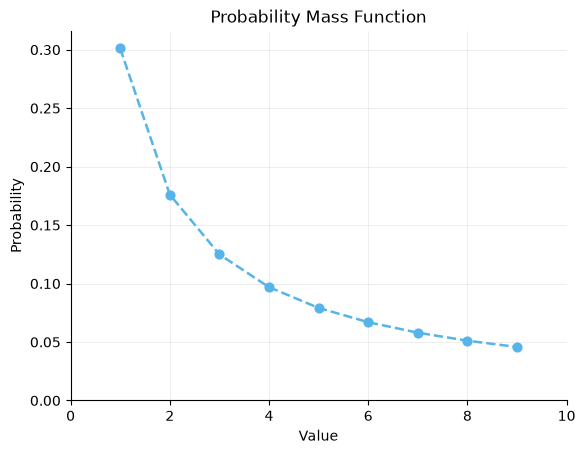

In [7]:
Benford().plot()

## Plot the CDF

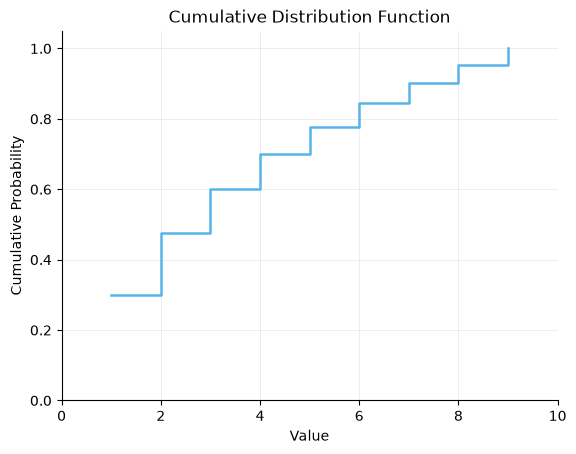

In [8]:
Benford().plot(cdf=True)

## Simulation against the exact pmf

A histogram of simulated digits with the exact masses drawn over it.

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


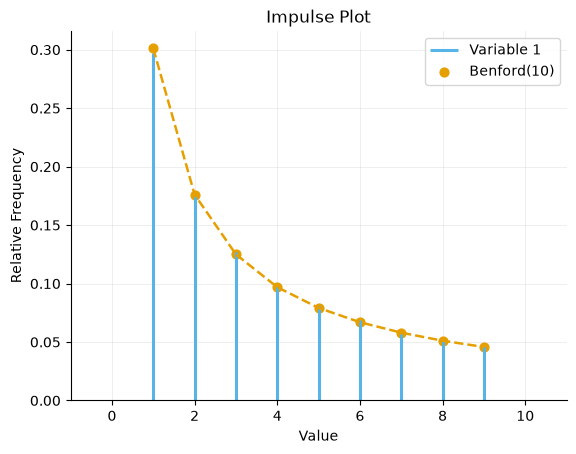

In [9]:
D.sim(10000).plot()
Benford().plot()

## The base changes how many digits there are

Base 16 runs over the digits 1 to 15, and its leading-1 probability is exactly 1/4, since `log_16(2) = 1/4`.

In [10]:
Benford(base=16).pmf(1), Benford(base=8).mean(), Benford(base=16).mean()

(np.float64(0.25),
 np.float64(2.900263993870907),
 np.float64(4.937464882529344))

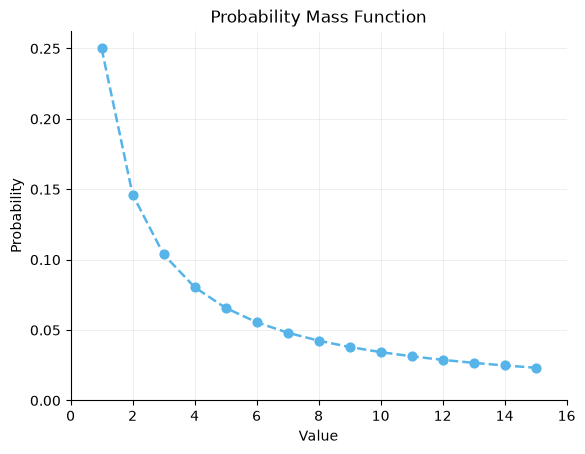

In [11]:
Benford(base=16).plot()

## Base 2 is a legitimate edge case

In binary the only possible leading digit is 1, so the distribution is a point mass there.

In [12]:
Benford(base=2).pmf(1), Benford(base=2).mean(), Benford(base=2).var()

(np.float64(1.0), np.float64(1.0), np.float64(0.0))

## Where the law comes from

Benford's law is what you get when the *logarithm* of a quantity is spread evenly. A value leads with digit `d` exactly when its fractional log part falls in `[log10(d), log10(d + 1))`, and the width of that interval is `log10(1 + 1/d)`.

Simulating a uniform log and reading off the leading digit reproduces the law -- no appeal to real-world data needed.

In [13]:
leading_digit = RV(Uniform(a=0, b=1)).apply(lambda u: int(10 ** u))
leading_digit.sim(10000).tabulate(normalize=True)

1,0.3003
2,0.1742
3,0.1255
4,0.0943
5,0.0767
6,0.0674
7,0.0648
8,0.051
9,0.0458
Total,1.0


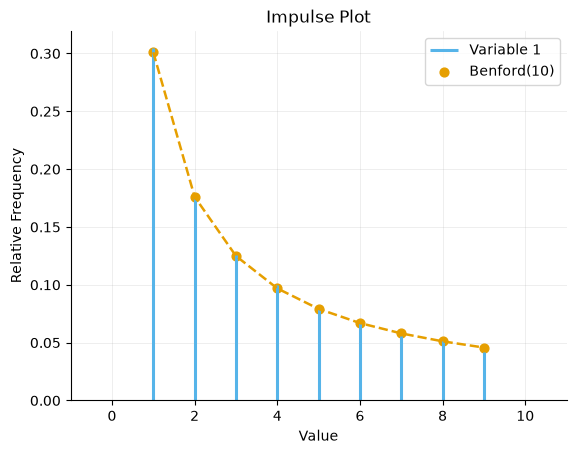

In [14]:
leading_digit.sim(10000).plot()
Benford().plot()